In [34]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [35]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

    country  year  incidence  mortality           gdp       bmi    pop_65  \
0      chad  1990  11.784239  15.747424   1705.042265  0.038681  3.455495   
1     india  1990   8.650421   8.913174   2203.147039  0.014403  4.037870   
2      oman  1990   5.197615   6.765138  35201.552487  0.052449  2.453040   
3    zambia  1990  14.798816  20.414687   2425.111287  0.110025  2.880287   
4  djibouti  1990  15.847623  16.948879           NaN  0.061933  2.993589   

   urban_pop  life_exp  fertility  labor_rate  internet  broadband  \
0     20.811    48.799      7.219      64.570       0.0        NaN   
1     25.547    59.358      4.045      30.225       0.0        NaN   
2     66.102    71.752      6.456      22.489       0.0        NaN   
3     39.407    49.410      6.567      51.414       0.0        NaN   
4     75.957    57.445      5.931      16.026       0.0        NaN   

   health_exp  smoking  
0         NaN      3.3  
1         NaN     40.8  
2         NaN      0.6  
3         NaN   

In [36]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

173


In [37]:
initial_years=final_df['year'].nunique()
print(initial_years)

34


# OECD  Countries :

In [38]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'colombia', 'czechia', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovakia', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkiye', 'united kingdom', 'united states', 'costa rica']
print(len(oecd_countries))

38


# Creat Dummy Variables:

In [39]:
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    4647
1    1156
Name: count, dtype: int64


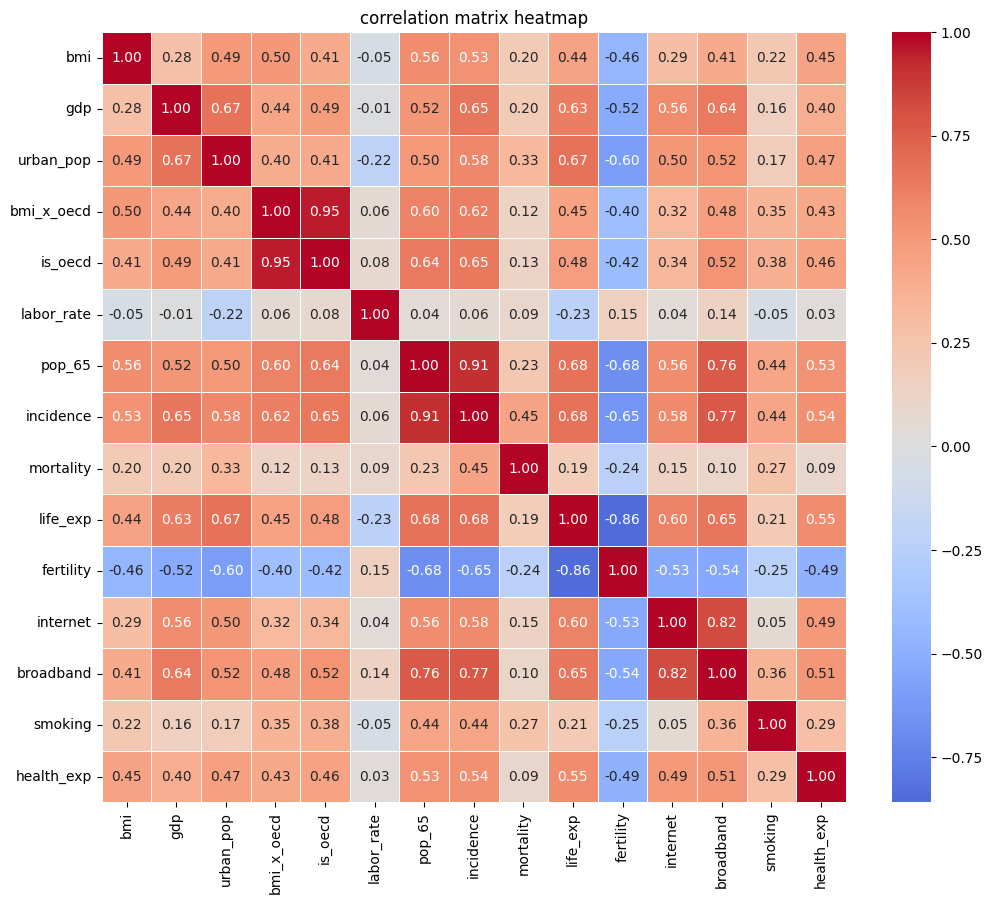

In [40]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'mortality', 'life_exp', 'fertility','internet', 'broadband','smoking','health_exp']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [41]:
oecd_comparison= final_df.groupby('is_oecd').incidence.mean()
print(final_df['is_oecd'].value_counts())

is_oecd
0    4647
1    1156
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [42]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    4044
1    1759
Name: count, dtype: int64


2. High Life Expectancy Dummy threshold of 75 years represents advanced healthcare systems and higher probability of disease detection.

In [43]:
final_df['dm_high_life_exp']=(final_df['life_exp']> 75).astype(int)
print(final_df['dm_high_life_exp'].value_counts())

dm_high_life_exp
0    3172
1    2631
Name: count, dtype: int64


In [44]:
comparison_mortal= final_df.groupby('dm_high_life_exp').mortality.mean()
print(comparison_mortal)

dm_high_life_exp
0    18.018808
1    20.623244
Name: mortality, dtype: float64


In [45]:
comparison_mortal= final_df.groupby('dm_high_life_exp').mortality.mean()
print(comparison_mortal)

dm_high_life_exp
0    18.018808
1    20.623244
Name: mortality, dtype: float64


In [46]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].head(100))

    year                   country  is_oecd  dm_high_aging_society  \
0   1990                      chad        0                      0   
1   1990                     india        0                      0   
2   1990                      oman        0                      0   
3   1990                    zambia        0                      0   
4   1990                  djibouti        0                      0   
..   ...                       ...      ...                    ...   
95  1990                   andorra        0                      0   
96  1990                 nicaragua        0                      0   
97  1990                 indonesia        0                      0   
98  1990                uzbekistan        0                      0   
99  1990  northern mariana islands        0                      0   

    dm_high_life_exp  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  
..               ... 

# interaction of is_oecd variable and gdp

In [47]:
final_df['log_gdp']= np.log(final_df['gdp'])
final_df['log_gdp_is_oecd']= final_df['log_gdp']*final_df['is_oecd']
print(final_df['log_gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    0.0
3    0.0
4    NaN
Name: log_gdp_is_oecd, dtype: float64


In [48]:
final_df['is_oecd'] = 0
final_df.loc[final_df['country'].isin(oecd_countries), 'is_oecd'] = 1

# interaction of is_oecd variable and gdp
final_df['log_gdp'] = np.log(final_df['gdp'])
final_df['log_gdp_is_oecd'] = final_df['log_gdp'] * final_df['is_oecd']
# Filling NaNs in Interaction Term: Since 'NaN * 0 = NaN' in Python, rows where is_oecd is 0 but log_gdp is missing(NAN) 
# would incorrectly stay as NaN (and be counted in the results), then filled these with 0 to ensure only real OECD countries with data are counted.
final_df['log_gdp_is_oecd'] = final_df['log_gdp_is_oecd'].fillna(0)

# counting contries :
oecd_count = final_df[final_df['is_oecd'] == 1]['country'].nunique()
interaction_countries = final_df[final_df['log_gdp_is_oecd'] != 0]['country'].nunique()

In [49]:
#print(final_df[['year', 'country', 'gdp_is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
print(final_df[['country','gdp','is_oecd','log_gdp_is_oecd','dm_high_aging_society', 'dm_high_life_exp']].sample(15).round(2))

                       country       gdp  is_oecd  log_gdp_is_oecd  \
3539                 guatemala  10126.83        0             0.00   
1294                     malta  24008.00        0             0.00   
4128                    malawi   1504.38        0             0.00   
979                   cambodia   1643.02        0             0.00   
3088  central african republic   1219.59        0             0.00   
323                     norway  58588.47        1            10.98   
2714                    belize  12900.11        0             0.00   
758                    eritrea       NaN        0             0.00   
5046          papua new guinea   4275.75        0             0.00   
2596                montenegro  17703.32        0             0.00   
4018                    france  50326.57        1            10.83   
2533                  zimbabwe   3701.46        0             0.00   
3921              sierra leone   2815.06        0             0.00   
1792               a

In [50]:
start_year=final_df['year'].min()
end_year=final_df['year'].max()
print(final_df[['year', 'country', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
start_count= final_df[final_df['year']== start_year]['dm_high_life_exp'].sum() 
end_count=final_df[final_df['year']== end_year]['dm_high_life_exp'].sum()
print(f"number of countries with high life_expectency in {start_count}")
print(f"number of countries with high life_expectency in {end_count}")

      year                   country  dm_high_aging_society  dm_high_life_exp
5703  2021                  zimbabwe                      0                 0
5704  2021  central african republic                      0                 0
5705  2021                   bahrain                      0                 1
5706  2021                madagascar                      0                 0
5707  2021                    malawi                      0                 0
...    ...                       ...                    ...               ...
5798  2023                    monaco                      1                 1
5799  2023                  dominica                      1                 0
5800  2023                 argentina                      1                 1
5801  2023        dominican republic                      0                 1
5802  2023                     nauru                      0                 0

[100 rows x 4 columns]
number of countries with high life_expec

# delet percentage of rows with missing value(NA):

In [ ]:
missing_report = (final_df.isnull().sum() / len(final_df)) * 100
print(missing_report[missing_report > 0]) 

--- 📊 Percentage of Missing Values ---
gdp            3.653283
labor_rate     8.064794
internet      13.337929
broadband     40.496295
health_exp    34.103050
smoking       15.043943
log_gdp        3.653283
dtype: float64


In [52]:
clean_df= final_df.dropna(subset=['mortality', 'gdp', 'pop_65', 'urban_pop', 'life_exp', 'fertility', 'labor_rate', 'log_gdp_is_oecd', 'internet', 'broadband', 'health_exp', 'smoking'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                  0
year                     0
incidence                0
mortality                0
gdp                      0
bmi                      0
pop_65                   0
urban_pop                0
life_exp                 0
fertility                0
labor_rate               0
internet                 0
broadband                0
health_exp               0
smoking                  0
is_oecd                  0
bmi_x_oecd               0
dm_high_aging_society    0
dm_high_life_exp         0
log_gdp                  0
log_gdp_is_oecd          0
dtype: int64


# Building stepwise regression

# Step 1: Adding gdp and urbanisation:

In [53]:
df_step= clean_df.set_index(['country', 'year'])
exog_1_fe= sm.add_constant(df_step[['log_gdp', 'urban_pop']])
model_1_fe=PanelOLS(df_step['mortality'],exog_1_fe, entity_effects=True, time_effects=True).fit()
print(model_1_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1173
Estimator:                   PanelOLS   R-squared (Between):             -3.0418
No. Observations:                2678   R-squared (Within):              -0.0836
Date:                Mon, Mar 09 2026   R-squared (Overall):             -2.6165
Time:                        15:17:25   Log-likelihood                   -5775.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      167.13
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(2,2516)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             167.13
                            

# Step 2: Adding Pop_65:

In [54]:
exog_2_fe = df_step[['log_gdp', 'urban_pop', 'pop_65']]
model_2_fe = PanelOLS(df_step['mortality'], exog_2_fe, entity_effects=True, time_effects=True).fit()
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2491
Estimator:                   PanelOLS   R-squared (Between):              0.0598
No. Observations:                2678   R-squared (Within):               0.2268
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.0235
Time:                        15:17:25   Log-likelihood                   -5559.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      278.10
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(3,2515)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             278.10
                            

# Step 3: Adding Labor Rate:

In [55]:
exog_3_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_3_fe=PanelOLS(df_step['mortality'], exog_3_fe, entity_effects=True, time_effects=True).fit()
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2725
Estimator:                   PanelOLS   R-squared (Between):             -2.0449
No. Observations:                2678   R-squared (Within):               0.2564
Date:                Mon, Mar 09 2026   R-squared (Overall):             -1.7940
Time:                        15:17:25   Log-likelihood                   -5516.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      235.47
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(4,2514)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             235.47
                            

# Step 4: Adding BMI:

In [56]:
exog_4_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_4_fe=PanelOLS(df_step['mortality'], exog_4_fe, entity_effects=True, time_effects= True).fit()
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2837
Estimator:                   PanelOLS   R-squared (Between):             -1.9649
No. Observations:                2678   R-squared (Within):               0.2586
Date:                Mon, Mar 09 2026   R-squared (Overall):             -1.7057
Time:                        15:17:25   Log-likelihood                   -5495.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      199.10
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(5,2513)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             199.10
                            

# Step 5:Adding is_oecd as Dummy Variable:

In [57]:
exog_5_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd']])
model_5_fe=PanelOLS(df_step['mortality'], exog_5_fe, entity_effects=True, time_effects=True).fit()
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2928
Estimator:                   PanelOLS   R-squared (Between):             -10.334
No. Observations:                2678   R-squared (Within):               0.2704
Date:                Mon, Mar 09 2026   R-squared (Overall):             -10.050
Time:                        15:17:25   Log-likelihood                   -5478.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      173.35
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(6,2512)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             173.35
                            

# Step 6: Adding High aging society as Dummy Variable:

In [58]:
exog_6_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society']])
model_6_fe = PanelOLS(df_step['mortality'], exog_6_fe, entity_effects=True, time_effects=True).fit()
print(model_6_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3000
Estimator:                   PanelOLS   R-squared (Between):             -10.399
No. Observations:                2678   R-squared (Within):               0.2786
Date:                Mon, Mar 09 2026   R-squared (Overall):             -10.111
Time:                        15:17:25   Log-likelihood                   -5465.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      153.77
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(7,2511)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             153.77
                            

# Step 7: Adding High life exp as Dummy Variable:

In [59]:
exog_7_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp']])
model_7_fe = PanelOLS(df_step['mortality'], exog_7_fe, entity_effects=True, time_effects= True).fit()
print(model_7_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3001
Estimator:                   PanelOLS   R-squared (Between):             -10.484
No. Observations:                2678   R-squared (Within):               0.2786
Date:                Mon, Mar 09 2026   R-squared (Overall):             -10.193
Time:                        15:17:25   Log-likelihood                   -5465.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      134.50
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(8,2510)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             134.50
                            

# create labor_rate * is_oecd variable:

In [60]:
df_step['labor_rate * is_oecd']= df_step['labor_rate']* df_step['is_oecd']

# Step 8: Adding labor_rate * is_oecd:

In [61]:
exog_8_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society',
                                     'dm_high_life_exp', 'labor_rate * is_oecd']])
model_8_fe = PanelOLS(df_step['mortality'], exog_8_fe, entity_effects=True, time_effects= True).fit()
print(model_8_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3012
Estimator:                   PanelOLS   R-squared (Between):             -9.4968
No. Observations:                2678   R-squared (Within):               0.2787
Date:                Mon, Mar 09 2026   R-squared (Overall):             -9.2309
Time:                        15:17:26   Log-likelihood                   -5462.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      120.17
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(9,2509)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             120.17
                            

# Step 9: Adding internet:

In [62]:
exog_9_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet']])
model_9_fe = PanelOLS(df_step['mortality'], exog_9_fe, entity_effects=True, time_effects= True).fit()
print(model_9_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3103
Estimator:                   PanelOLS   R-squared (Between):             -9.4985
No. Observations:                2678   R-squared (Within):               0.2003
Date:                Mon, Mar 09 2026   R-squared (Overall):             -9.2473
Time:                        15:17:26   Log-likelihood                   -5445.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      112.85
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(10,2508)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             112.85
                            

# Step  10: Adding broadband:

In [63]:
exog_10_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband']])
model_10_fe = PanelOLS(df_step['mortality'], exog_10_fe, entity_effects=True, time_effects= True).fit()
print(model_10_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4177
Estimator:                   PanelOLS   R-squared (Between):             -5.5302
No. Observations:                2678   R-squared (Within):               0.2429
Date:                Mon, Mar 09 2026   R-squared (Overall):             -5.3605
Time:                        15:17:26   Log-likelihood                   -5218.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      163.47
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(11,2507)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             163.47
                            

# Step  11: Adding smoking:

In [64]:
exog_11_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet',
                                       'broadband','smoking']])
model_11_fe = PanelOLS(df_step['mortality'], exog_11_fe, entity_effects=True, time_effects= True).fit()
print(model_11_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4215
Estimator:                   PanelOLS   R-squared (Between):             -4.3136
No. Observations:                2678   R-squared (Within):               0.1537
Date:                Mon, Mar 09 2026   R-squared (Overall):             -4.1818
Time:                        15:17:26   Log-likelihood                   -5209.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      152.16
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(12,2506)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             152.16
                            

# step 12: adding health_exp:

In [65]:
exog_12_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society',
                                      'dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking','health_exp']])
model_12_fe = PanelOLS(df_step['mortality'], exog_12_fe, entity_effects=True, time_effects= True).fit()
print(model_12_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4216
Estimator:                   PanelOLS   R-squared (Between):             -4.3043
No. Observations:                2678   R-squared (Within):               0.1529
Date:                Mon, Mar 09 2026   R-squared (Overall):             -4.1727
Time:                        15:17:26   Log-likelihood                   -5209.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      140.43
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(13,2505)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             140.43
                            

# Comparing results of all Fixed Effect models:

In [66]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe,
    'FE model 6': model_6_fe,
    'FE model 7': model_7_fe,
    'FE model 8': model_8_fe,
    'FE model 9': model_9_fe,
    'FE model 10': model_10_fe,
    'FE model 11': model_11_fe,
    'FE model 12': model_12_fe })
print(Compare_results_fixed_Effect)

                                                                                               Model Comparison                                                                                              
                              FE model 1     FE model 2     FE model 3     FE model 4     FE model 5     FE model 6     FE model 7     FE model 8     FE model 9    FE model 10    FE model 11    FE model 12
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                  mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality
Estimator                       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS 